In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/keerthuramu/sample-submission/sample_submission.csv
/kaggle/input/datasets/keerthuramu/train-tabular/train_tabular.csv
/kaggle/input/datasets/keerthuramu/evaluation-data/evaluation_tabular_no_target.csv


In [2]:
!pip install lightgbm -q

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/keerthuramu/sample-submission/sample_submission.csv
/kaggle/input/datasets/keerthuramu/train-tabular/train_tabular.csv
/kaggle/input/datasets/keerthuramu/evaluation-data/evaluation_tabular_no_target.csv


In [4]:
import pandas as pd
import numpy as np

# Train path confirmed ✅
train = pd.read_csv('/kaggle/input/datasets/keerthuramu/train-tabular/train_tabular.csv')

# Fill these once you upload evaluation CSV
# test  = pd.read_csv('/kaggle/input/YOUR_PATH/evaluation.csv')
# sample = pd.read_csv('/kaggle/input/YOUR_PATH/sample_submission.csv')

print("Train shape:", train.shape)
print(train.columns.tolist())
print(train.head(2))

Train shape: (1024, 23)
['data_id', 'geolocation_name', 'quarter_label', 'country', 'year', 'deflated_gdp_usd', 'us_cpi', 'developed_country', 'landlocked', 'region_economic_classification', 'access_to_airport', 'access_to_port', 'access_to_highway', 'access_to_railway', 'straight_distance_to_capital_km', 'seismic_hazard_zone', 'flood_risk_class', 'tropical_cyclone_wind_risk', 'tornadoes_wind_risk', 'koppen_climate_zone', 'sentinel2_tiff_file_name', 'viirs_tiff_file_name', 'construction_cost_per_m2_usd']
  data_id geolocation_name quarter_label      country  year  deflated_gdp_usd  \
0   LP81L  Dinagat Islands       2019-Q3  Philippines  2019      2.996821e+11   
1   E7EOB       29000 Nara       2024-Q2        Japan  2024      3.928801e+12   

       us_cpi developed_country landlocked region_economic_classification  \
0  117.689915                No         No            Lower-middle income   
1  143.968241               Yes        Yes                    High income   

   ... access_

Min: 45.45076930004778
Max: 3628.201593983225
Mean: 1109.3114860347114
Nulls in data: 4


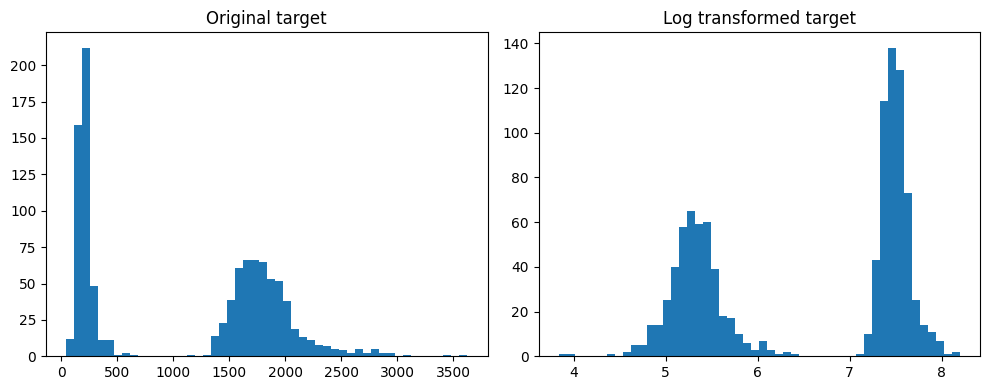

In [5]:
# Check target distribution
import matplotlib.pyplot as plt

target = train['construction_cost_per_m2_usd']
print("Min:", target.min())
print("Max:", target.max())
print("Mean:", target.mean())
print("Nulls in data:", train.isnull().sum().sum())

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(target, bins=50)
plt.title('Original target')

plt.subplot(1,2,2)
plt.hist(np.log1p(target), bins=50)
plt.title('Log transformed target')
plt.tight_layout()
plt.show()

In [6]:
# Check where the 4 nulls are
print(train.isnull().sum()[train.isnull().sum() > 0])

tropical_cyclone_wind_risk    4
dtype: int64


In [7]:
TARGET = 'construction_cost_per_m2_usd'

cat_cols = [
    'geolocation_name', 'quarter_label', 'country',
    'region_economic_classification', 'koppen_climate_zone',
    'seismic_hazard_zone', 'flood_risk_class',
    'tropical_cyclone_wind_risk', 'tornadoes_wind_risk',
    'developed_country', 'landlocked',
    'access_to_airport', 'access_to_port',
    'access_to_highway', 'access_to_railway'
]

# Drop image columns
train = train.drop(columns=['sentinel2_tiff_file_name', 'viirs_tiff_file_name'])

# Fill nulls
train = train.fillna(-999)

print("Ready! Shape:", train.shape)
print(train[cat_cols].head(2))

Ready! Shape: (1024, 21)
  geolocation_name quarter_label      country region_economic_classification  \
0  Dinagat Islands       2019-Q3  Philippines            Lower-middle income   
1       29000 Nara       2024-Q2        Japan                    High income   

  koppen_climate_zone seismic_hazard_zone flood_risk_class  \
0                  Af            Moderate              Yes   
1                 Cfa            Moderate              Yes   

  tropical_cyclone_wind_risk tornadoes_wind_risk developed_country landlocked  \
0                       High            Very Low                No         No   
1                        Low            Very Low               Yes        Yes   

  access_to_airport access_to_port access_to_highway access_to_railway  
0                No            Yes               Yes                No  
1                No             No               Yes               Yes  


In [8]:
from sklearn.preprocessing import LabelEncoder

# Separate features and target
X = train.drop(columns=['data_id', TARGET])
y = np.log1p(train[TARGET])

# Encode all categorical columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print("X shape:", X.shape)
print("Features:", X.columns.tolist())
print(X.head(2))

X shape: (1024, 19)
Features: ['geolocation_name', 'quarter_label', 'country', 'year', 'deflated_gdp_usd', 'us_cpi', 'developed_country', 'landlocked', 'region_economic_classification', 'access_to_airport', 'access_to_port', 'access_to_highway', 'access_to_railway', 'straight_distance_to_capital_km', 'seismic_hazard_zone', 'flood_risk_class', 'tropical_cyclone_wind_risk', 'tornadoes_wind_risk', 'koppen_climate_zone']
   geolocation_name  quarter_label  country  year  deflated_gdp_usd  \
0                77              2        1  2019      2.996821e+11   
1                28             21        0  2024      3.928801e+12   

       us_cpi  developed_country  landlocked  region_economic_classification  \
0  117.689915                  0           0                               2   
1  143.968241                  1           1                               0   

   access_to_airport  access_to_port  access_to_highway  access_to_railway  \
0                  0               1          

In [9]:
from sklearn.model_selection import KFold
import xgboost as xgb

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(X))
test_preds_placeholder = []  # will fill after evaluation CSV loads

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    X_tr,  X_val = X.iloc[tr_idx],  X.iloc[val_idx]
    y_tr,  y_val = y.iloc[tr_idx],  y.iloc[val_idx]
    
    model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='rmse'
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    oof_preds[val_idx] = model.predict(X_val)
    
    rmsle = np.sqrt(np.mean((y_val - oof_preds[val_idx])**2))
    print(f"Fold {fold+1} RMSLE: {rmsle:.4f}")

overall = np.sqrt(np.mean((y - oof_preds)**2))
print(f"\nFinal OOF RMSLE: {overall:.4f}")

Fold 1 RMSLE: 0.2065
Fold 2 RMSLE: 0.1537
Fold 3 RMSLE: 0.2370
Fold 4 RMSLE: 0.2277
Fold 5 RMSLE: 0.1759

Final OOF RMSLE: 0.2026


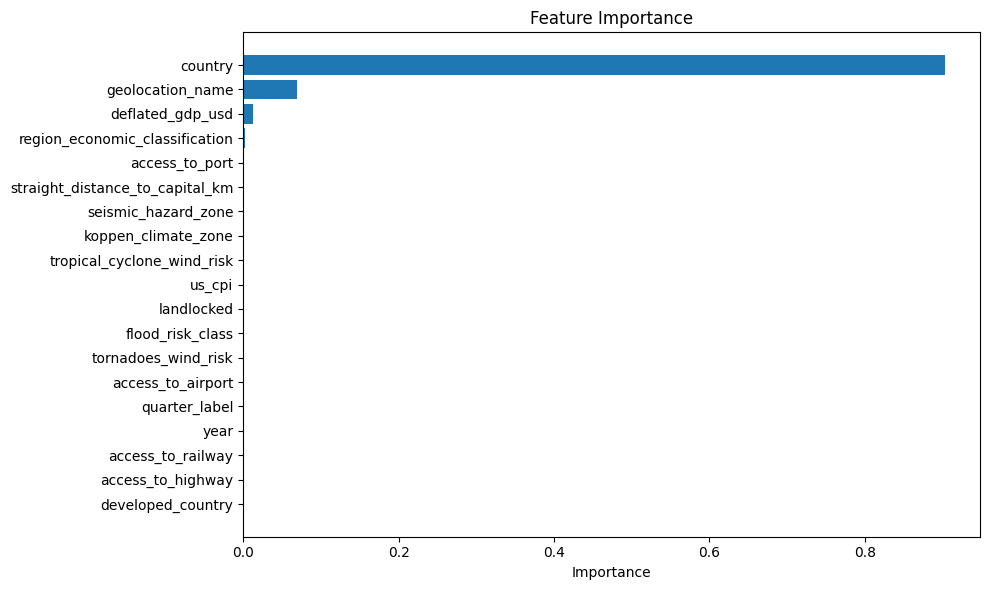

                            feature  importance
2                           country    0.903192
0                  geolocation_name    0.069602
4                  deflated_gdp_usd    0.012274
8    region_economic_classification    0.002314
10                   access_to_port    0.001394
13  straight_distance_to_capital_km    0.001380
14              seismic_hazard_zone    0.001280
18              koppen_climate_zone    0.001267
16       tropical_cyclone_wind_risk    0.001013
5                            us_cpi    0.000891
7                        landlocked    0.000884
15                 flood_risk_class    0.000833
17              tornadoes_wind_risk    0.000777
9                 access_to_airport    0.000757
1                     quarter_label    0.000707
3                              year    0.000706
12                access_to_railway    0.000644
11                access_to_highway    0.000085
6                 developed_country    0.000000


In [10]:
import matplotlib.pyplot as plt

# Use last fold's model
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_imp)

In [11]:
# Train on all 1024 rows — no validation split
# This gives stronger predictions for the test set

final_model = xgb.XGBRegressor(
    n_estimators=500,       # fixed iterations (no early stopping on full data)
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
final_model.fit(X, y, verbose=False)
print("Full model trained on all", len(X), "rows ✅")

Full model trained on all 1024 rows ✅


In [12]:
import lightgbm as lgb

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb   = np.zeros(len(X))
lgb_models = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    X_tr,  X_val = X.iloc[tr_idx],  X.iloc[val_idx]
    y_tr,  y_val = y.iloc[tr_idx],  y.iloc[val_idx]
    
    lgb_model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )
    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    
    oof_lgb[val_idx] = lgb_model.predict(X_val)
    lgb_models.append(lgb_model)
    
    rmsle = np.sqrt(np.mean((y_val - oof_lgb[val_idx])**2))
    print(f"Fold {fold+1} RMSLE: {rmsle:.4f}")

overall_lgb = np.sqrt(np.mean((y - oof_lgb)**2))
print(f"\nLightGBM OOF RMSLE: {overall_lgb:.4f}")
print(f"XGBoost  OOF RMSLE: 0.2026")

Fold 1 RMSLE: 0.2038
Fold 2 RMSLE: 0.1640
Fold 3 RMSLE: 0.2248
Fold 4 RMSLE: 0.2269
Fold 5 RMSLE: 0.1820

LightGBM OOF RMSLE: 0.2018
XGBoost  OOF RMSLE: 0.2026


In [13]:
final_lgb = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
final_lgb.fit(X, y)
print("LightGBM full model trained ✅")

LightGBM full model trained ✅


In [14]:
# Blend OOF predictions (50/50)
oof_blend = 0.5 * oof_preds + 0.5 * oof_lgb
blend_rmsle = np.sqrt(np.mean((y - oof_blend)**2))

print(f"XGBoost  RMSLE: 0.2026")
print(f"LightGBM RMSLE: 0.2018")
print(f"Blend    RMSLE: {blend_rmsle:.4f}")

XGBoost  RMSLE: 0.2026
LightGBM RMSLE: 0.2018
Blend    RMSLE: 0.2002


In [15]:
# Replace with actual path
test   = pd.read_csv('/kaggle/input/datasets/keerthuramu/evaluation-data/evaluation_tabular_no_target.csv')
sample = pd.read_csv('/kaggle/input/datasets/keerthuramu/sample-submission/sample_submission.csv')

# Drop image columns
test = test.drop(columns=['sentinel2_tiff_file_name', 'viirs_tiff_file_name'])
test = test.fillna(-999)

print("Test shape:", test.shape)
print(test.head(2))

Test shape: (1024, 20)
  data_id geolocation_name quarter_label country  year  deflated_gdp_usd  \
0   3TOW4      23000 Aichi       2019-Q4   Japan  2019      4.070265e+12   
1   493WX      10000 Gunma       2021-Q1   Japan  2021      4.247589e+12   

       us_cpi developed_country landlocked region_economic_classification  \
0  117.940616               Yes         No                    High income   
1  120.683801               Yes        Yes                    High income   

  access_to_airport access_to_port access_to_highway access_to_railway  \
0               Yes            Yes               Yes               Yes   
1                No             No               Yes               Yes   

   straight_distance_to_capital_km seismic_hazard_zone flood_risk_class  \
0                            260.0                High              Yes   
1                            100.0                High               No   

  tropical_cyclone_wind_risk tornadoes_wind_risk koppen_climate_zon

In [16]:
X_test = test.drop(columns=['data_id'])

# Encode same categorical columns
for col in cat_cols:
    le = LabelEncoder()
    X_test[col] = le.fit_transform(X_test[col].astype(str))

print("X_test shape:", X_test.shape)

X_test shape: (1024, 19)


In [17]:
# Blend both models
xgb_preds = final_model.predict(X_test)
lgb_preds = final_lgb.predict(X_test)
final_preds = 0.5 * xgb_preds + 0.5 * lgb_preds

# Convert from log space
final_preds = np.expm1(final_preds)
final_preds = np.clip(final_preds, 0, None)

# Save submission
submission = sample.copy()
submission['construction_cost_per_m2_usd'] = final_preds
submission.to_csv('submission.csv', index=False)

print("Done! ✅")
print(submission.head(10))

Done! ✅
  data_id  construction_cost_per_m2_usd
0   3TOW4                   1842.232204
1   493WX                   1613.103119
2   UYP04                   1750.358580
3   FN33V                    274.259957
4   CPRHV                   1704.437341
5   97PWD                    190.433478
6   74RS7                   1584.375626
7   JIPNF                   2026.868866
8   IA5U6                   1662.516222
9   EH5SW                   1512.892005


In [18]:
from IPython.display import FileLink
FileLink('submission.csv')

/kaggle/working/submission.csv